In [ ]:
### Response Curves 
# Build a grid of response curves by gdp and climtas
# Evaluate differences in response curve with/without adaptation
# Map the slope of the response curve at the forecast temp

In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date

import analysis_utils
import isku_utils
import plotting_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# Baseline period for Impact
BASELINE_PERIOD = slice("1996-01-01", "2025-12-31")
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260915",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=False, 
                                     months = FC_MONTHS,
                                     hotonly = "hotonly", 
                                     dims = ['number', 'sample'])


In [3]:
# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_PARSED_FORECAST_URI"]

s51 = xr.open_zarr(TAS_FORECAST_RAW)
forecast = s51.sel(time=FC_PERIOD).groupby("time.month").mean()-273.15
forecast_ir = isku_utils.grid_to_ir(forecast.compute(), savefile=None)

forecast_ds = forecast_ir.assign(
    forecast_mean=forecast_ir['tas'].mean(dim=['number']),
    forecast_std=forecast_ir['tas'].std(dim=['number'])
)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [4]:
def merge_regions(ds, socioec_ds, forecast_ds):
    if isinstance(ds, xr.DataTree):
        ds = ds.to_dataset()
    merged = xr.merge([
        ds,
        socioec_ds[['pop']],
        forecast_ds[['forecast_mean', 'forecast_std']]
    ], join='inner')

    return merged

def filter_regions(merged, min_population, min_dist_from_mmt, max_dist_from_mmt):
    """
     select regions where population >= min_population and
    |forecast_mean - mmt| <= max_dist_from_mmt.

    mmt in ds has dims (sample, age_cohort, region) — collapsed across sample/age_cohort
    (mean) to get a single per-region MMT for the distance filter.
    """
    mmt_per_region = merged['mmt'].mean(dim=['sample', 'age_cohort'])
    dist_from_mmt = np.abs(merged['forecast_mean'] - mmt_per_region)

    region_mask = (merged['pop'] >= min_population) & (dist_from_mmt <= max_dist_from_mmt)& (dist_from_mmt >= min_dist_from_mmt)
    selected_regions = merged['region'].values[region_mask.values]

    return merged.sel(region=selected_regions)

In [5]:
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/v20260909_effects_with_betas.zarr"
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)

In [6]:
# Load Betas
# September Projection - No Adaptation
ds1 = effect['/fixed_beta']
ds1 = merge_regions(ds1, config.socioeconomics, forecast_ds).compute()
# Filter regions w/ 0 pop
ds1 = ds1.where(ds1['pop'] > 1, drop=True)
# Adaptation based on Annual CMIP6 (SSP370)
ds2 = xr.open_dataset("/home/emily_zuetell/projects/poreallas/data/beta_cmip6_2045.zarr")
ds2 = merge_regions(ds2, config.socioeconomics, forecast_ds).compute()
# Filter regions w/ 0 pop
ds2 = ds2.where(ds2['pop'] > 1, drop=True)

(-10.0, 15.0)

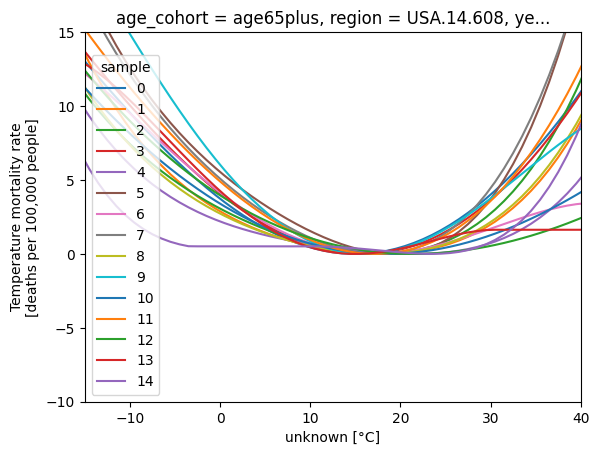

In [30]:
ds1.sel(region = 'USA.14.608').sel(age_cohort = 'age65plus')['beta'].plot.line(x = 'tas_bin')
plt.xlim(-15, 40)
plt.ylim(-10, 15)

In [31]:
ds1.sel(region = 'ARE.1').sel(age_cohort = 'age65plus')['mmt']

<xarray.DataArray 'mmt' (sample: 15)> Size: 60B
array([10.5, 10.5, 10.5, 10.5, 10.5, 29.5, 10.5, 29.5, 29.5, 10.5, 10.5,
       10.5, 29.5, 10.5, 10.5], dtype=float32)
Coordinates:
  * sample      (sample) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    age_cohort  StringDType() 16B 'age65plus'
    region      StringDType() 16B 'ARE.1'
    year        int64 8B 2026
Attributes: (12/43)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    poreallas_sim_stop_year:                  2027
    poreallas_qdm_nquantiles:                 100
    poreallas_ref_uri:                        gs://poreallas-public-20260605/...
    poreallas_hist_uri:                       gs://poreallas-public-20260605/...
    poreallas_sim_uri:                        gs://poreallas-public-20260605/...
    units_metadata:                           temperature: unknown

(-10.0, 15.0)

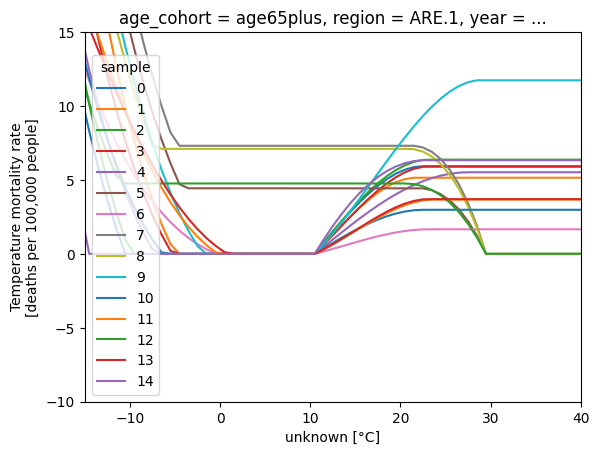

In [29]:

ds1.sel(region = 'ARE.1').sel(age_cohort = 'age65plus')['beta'].plot.line(x = 'tas_bin')
plt.xlim(-15, 40)
plt.ylim(-10, 15)

In [17]:
def plot_beta_grid_by_climate_gdp(ds, ds2=None, n_bins=4, age_cohort='age5to64', sample_agg='mean',
                                   label1='ds1', label2='ds2'):
    """
    Bin impact regions into a climtas (x) x loggdppc (y) grid and plot
    the beta response curve for each cell.

    ds : xarray Dataset/DataMapping with 'beta', 'climtas', 'loggdppc', 'tas_bin', 'region', 'age_cohort'
    ds2 : optional second dataset with 'beta' for the same regions, plotted in a second color
    n_bins : number of bins per axis
    age_cohort : which age cohort to plot ('age0to4','age5to64','age65plus')
    sample_agg : 'mean' or 'median' to collapse the sample dimension
    """
    climtas = ds['climtas'].values
    loggdppc = ds['loggdppc'].values

    # bin edges via quantiles: each cell has roughly equal region counts
    x_edges = np.nanquantile(climtas, np.linspace(0, 1, n_bins + 1))
    y_edges = np.nanquantile(loggdppc, np.linspace(0, 1, n_bins + 1))
    x_bin_idx = np.clip(np.digitize(climtas, x_edges[1:-1]), 0, n_bins - 1)
    y_bin_idx = np.clip(np.digitize(loggdppc, y_edges[1:-1]), 0, n_bins - 1)

    def _prep_beta(dset):
        # Select age_cohort, reduce samples
        b = dset['beta'].sel(age_cohort=age_cohort)  # dims: sample, region, tas_bin
        return b.reduce(np.nanmean if sample_agg == 'mean' else np.nanmedian, dim='sample')

    beta = _prep_beta(ds)
    beta2 = _prep_beta(ds2) if ds2 is not None else None
    #x-axis values
    tas_bin = ds['tas_bin'].values

    fig, axes = plt.subplots(n_bins, n_bins, figsize=(3 * n_bins, 3 * n_bins),
                              sharex=True, sharey=True)

    for xi in range(n_bins):
        for yi in range(n_bins):
            # row 0 = highest loggdppc (top): Flip y for display
            row = n_bins - 1 - yi
            ax = axes[row, xi]
            mask = (x_bin_idx == xi) & (y_bin_idx == yi)
            regions_in_cell = ds['region'].values[mask]

            # Check for regions in cell
            if len(regions_in_cell) == 0:
                ax.set_visible(False)
                continue
            # Individual response curve
            curves = beta.sel(region=regions_in_cell).values  # (n_regions, tas_bin)
            for curve in curves:
                ax.plot(tas_bin, curve, color='lightgray', lw=0.5, alpha=0.6, zorder=1)
            # Mean response curve
            mean_curve = np.nanmean(curves, axis=0)
            ax.plot(tas_bin, mean_curve, color='C0', lw=1.5, label=label1, zorder=2)

            # Plot additional betas
            if beta2 is not None:
                curves2 = beta2.sel(region=regions_in_cell).values
                for curve in curves2:
                    ax.plot(tas_bin, curve, color='mistyrose', lw=0.5, alpha=0.6, zorder=1)
                mean_curve2 = np.nanmean(curves2, axis=0)
                ax.plot(tas_bin, mean_curve2, color='C1', lw=1.5, label=label2, zorder=2)
            # Set limits to align w/ Carleton et al.
            ax.set_xlim(-15, 40)
            ax.set_ylim(-20, 60)
            ax.axhline(0, color='gray', lw=0.5)
            ax.set_title(f"n={mask.sum()}", fontsize=8)

            if xi == 0:
                ax.set_ylabel(f"loggdppc\n[{y_edges[yi]:.1f}, {y_edges[yi+1]:.1f})", fontsize=8)
            if row == n_bins - 1:
                ax.set_xlabel(f"climtas\n[{x_edges[xi]:.1f}, {x_edges[xi+1]:.1f})", fontsize=8)

    if ds2 is not None:
        axes[0, 0].legend(fontsize=7, loc='upper left')

    fig.suptitle(f"Response curves (Beta) by climtas x loggdppc grid ({age_cohort})")
    fig.supylabel("deaths/100k")
    fig.supxlabel("tas_bin (°C)")
    fig.tight_layout()
    return fig, axes

(<Figure size 900x900 with 9 Axes>,
 array([[<Axes: title={'center': 'n=4928'}, ylabel='loggdppc\n[9.6, 12.2)'>,
         <Axes: title={'center': 'n=2668'}>,
         <Axes: title={'center': 'n=497'}>],
        [<Axes: title={'center': 'n=2228'}, ylabel='loggdppc\n[8.4, 9.6)'>,
         <Axes: title={'center': 'n=3523'}>,
         <Axes: title={'center': 'n=2341'}>],
        [<Axes: title={'center': 'n=936'}, xlabel='climtas\n[-18.0, 15.3)', ylabel='loggdppc\n[5.8, 8.4)'>,
         <Axes: title={'center': 'n=1901'}, xlabel='climtas\n[15.3, 24.1)'>,
         <Axes: title={'center': 'n=5255'}, xlabel='climtas\n[24.1, 31.7)'>]],
       dtype=object))

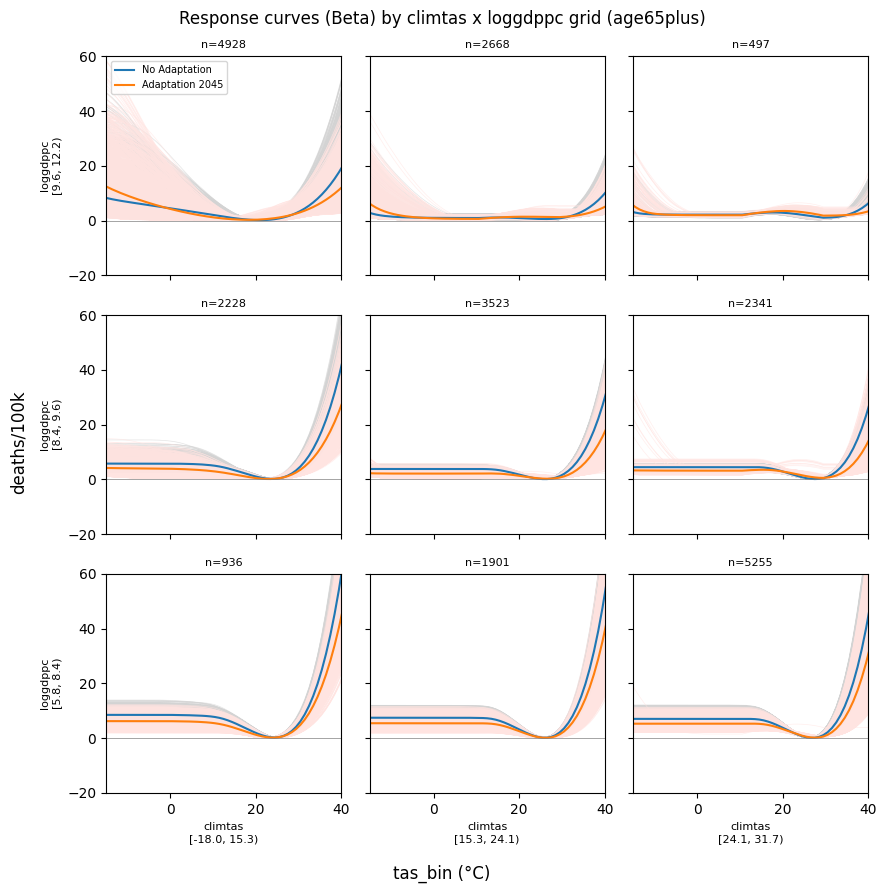

In [18]:
plot_beta_grid_by_climate_gdp(ds1, ds2, n_bins=3, age_cohort='age65plus', sample_agg='mean', 
                              label1='No Adaptation', label2='Adaptation 2045')

In [ ]:
## Investigate outlier response curves
check = ds1.sel(tas_bin = -5, method = 'nearest').sel(age_cohort = 'age65plus').mean(dim = 'sample')
# Where the clipped beta > 20 deaths/100k 
# Note: will also capture some "high income" regions that aren't outliers
outlier_mask = (check['beta'] >= 20)
outlier_regions = check['region'].values[outlier_mask.values]
check = check.sel(region = outlier_regions)

In [49]:
def compute_slope_at_forecast(merged):
    """
    Compute d(beta)/d(tas) evaluated at each region's forecast_mean,
    for every sample and age_cohort.
    """
    tas_bin = merged['tas_bin'].values

    def _slope_at_point(beta_curve, x0):
        # beta_curve: 1D array over tas_bin; x0: scalar forecast_mean for this region
        dbeta_dtas = np.gradient(beta_curve, tas_bin)
        return np.interp(x0, tas_bin, dbeta_dtas)

    slope = xr.apply_ufunc(
        _slope_at_point,
        merged['beta'],
        merged['forecast_mean'],
        input_core_dims=[['tas_bin'], []],
        output_core_dims=[[]],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[merged['beta'].dtype],
    )

    return slope.rename('beta_slope_at_forecast')

In [ ]:
slope = compute_slope_at_forecast(ds1.sel(age_cohort = 'age65plus'))

In [79]:
_polygons_slope = analysis_utils.xarray_to_gpd(
    slope.mean(dim="sample"), config.polygons
)

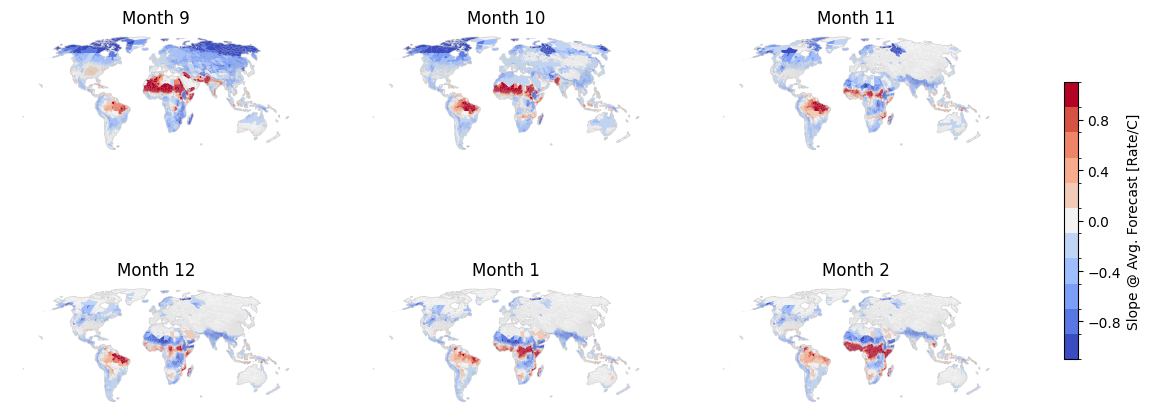

In [80]:
fig = plotting_utils.plot_monthly(
    _polygons_slope,
    col="beta_slope_at_forecast",
    cm="coolwarm",
    vmin=-1,
    vmax=1,
    n_colors=10,
    sup_title="",
    cbar_label="Slope @ Avg. Forecast [Rate/C]",
    month_order = config.months
)

In [53]:
_polygons_slope_09 = analysis_utils.xarray_to_gpd(
    slope.quantile(0.9, dim="sample"), config.polygons
)

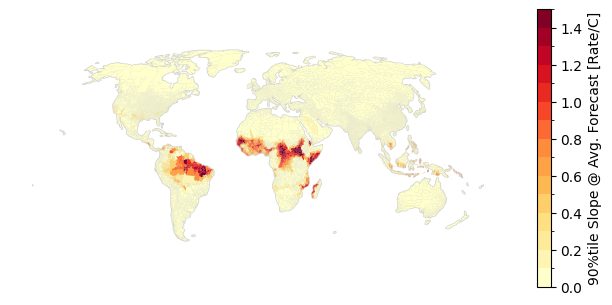

In [54]:
fig = plotting_utils.plot_single(
    _polygons_slope_09,
    col="beta_slope_at_forecast",
    cm="YlOrRd",
    vmin=0,
    vmax=1.5,
    n_colors=10,
    sup_title="",
    cbar_label="90%tile Slope @ Avg. Forecast [Rate/C]"
)